Universidade Federal do ABC (UFABC)  
Curso: Bacharelado em Ciências Econômicas  
Disciplina: Economia Matemática  
Período: 2º Quadrimestre de 2026  
Turmas: Matutino (DA2ESHC027-21SB) e Noturno (NA2ESHC027-21SB)  
Lista de Exercícios: Lista 3 (Aulas 13 a 17) | Entrega: 14 de agosto de 2026 (sexta-feira) 
  
Prof. Dr. Elson Rodrigo de Souza Santos  
WhatsApp: (41) 9 8454 0549 | E-mail: elson129@gmail.com ou elson.rodrigo@ufabc.edu.br | Repositório: github.com/elsonr29  
11 de agosto de 2026  

RESOLUÇÃO DA LISTA I

Observações:
    
1) Utilizamos o Python e os fundamentos da "quantitative economics", aula 40 - Linear programming < https://intro.quantecon.org/lp_intro.html > ;   
2) Os resultados devem ser coerentes com os obtidos manualmente; 
3) O Python é uma forma inclusiva de demonstrar os conceitos e modelos apresentados e discutidos em sala de aula;  
4) A ênfase é a parte quantitativa da lista de exercícios. 

In [64]:
# Pacotes

# Instação (se necessário)

!pip install numpy sympy matplotlib

#Obs.: Utilizamos o numpy para manipulação de matrizes e álgebra e o matplotlib para formatação de gráficos. Seguimos o caminho proposto pela Quantitative Economics.

Defaulting to user installation because normal site-packages is not writeable


In [65]:
# Carregamento

import numpy as np
import sympy as sp
import matplotlib as plt

# Obs.: após o carregamento é possível resolver a lista.

**1) Teoria da Firma -- Escolha Ótima da Quantidade Produzida**

Uma firma perfeitamente competitiva vende seu produto ao preço exógeno de mercado $p = 20$. A função de custo total da firma depende da quantidade produzida $y$ e é dada por:

$$CT(y) = 2y^2 + 4y + 10$$

A função de lucro da firma é dada pela diferença entre a Receita Total $RT(y) = p \cdot y$ e o Custo Total $CT(y)$:

$$\pi(y) = RT(y) - CT(y) = 20y - (2y^2 + 4y + 10)$$

Em seguida, responda às questões abaixo:

a) Simplifique a função de lucro $\pi(y)$ e determine a Condição de Primeira Ordem (CPO) para a maximização do lucro.

b) Reescreva a CPO no formato matricial $A y = d$ (sistema $1 \times 1$) e verifique a existência de uma solução única e determinada.

c) Utilize a Regra de Cramer para encontrar a quantidade ótima de produção $y^*$ e o lucro máximo $\pi^*$.

d) Calcule a derivada de segunda ordem da função de lucro (Hessiana $1 \times 1$) e demonstre se a Condição de Segunda Ordem (CSO) para um máximo local estrito é satisfeita.

e) Suponha que o preço de mercado suba para $p = 28$. Qual é o novo nível ótimo de produção $y^*$? Esta nova escolha satisfaz as CPO e CSO?

f) Apresente a representação gráfica do ponto de otimização (Receita Total, Custo Total e Lucro). Em seguida, explique como aumentos no preço de mercado $p$ alteram a quantidade produzida, preservando o atendimento às CPO e CSO.

In [66]:
# carregar pacotes

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [67]:
# a) CPO

import sympy as sp

# Definindo as variáveis e parâmetros simbólicos
y = sp.Symbol('y', positive=True)
p = sp.Symbol('p', positive=True)

# Definindo as funções de Receita Total, Custo Total e Lucro
RT = p * y
CT = 2*y**2 + 4*y + 10
pi = RT - CT

# Substituindo o preço de mercado p = 20
pi_num = pi.subs(p, 20)

# Calculando a derivada de primeira ordem (CPO): d(pi)/dy = 0
cpo = sp.diff(pi_num, y)

print(f"Função de Lucro Simplificada: {pi_num}")
print(f"Condição de Primeira Ordem (CPO): {cpo} = 0")

# Resolvendo a CPO para encontrar a quantidade ótima y*
y_otimo = sp.solve(cpo, y)
print(f"Quantidade Ótima (y*): {y_otimo[0]}")

Função de Lucro Simplificada: -2*y**2 + 16*y - 10
Condição de Primeira Ordem (CPO): 16 - 4*y = 0
Quantidade Ótima (y*): 4


In [68]:
# b) Em matriz Ax=d e calculo do determinante

# Definindo a matriz de coeficientes A e o vetor d (usando NumPy)
A = np.array([[4]])
d = np.array([[16]])

# Calculando o determinante da matriz A
det_A = np.linalg.det(A)

print(f"Matriz A: \n{A}")
print(f"Vetor d: \n{d}")
print(f"Determinante |A|: {det_A}")

# Verificando a existência de solução única
if det_A != 0:
    print("Como |A| != 0, o sistema possui uma solução única e determinada.")
    # Calculando a solução y = A^(-1) * d
    y_otimo = np.linalg.inv(A).dot(d)
    print(f"Solução ótima y*: {y_otimo[0, 0]}")
else:
    print("O determinante é zero; o sistema não possui solução única.")

# Obs. poderiamos fazer direto como no item a, devido a existir apenas uma variável de interesse que é o nível de produção y

Matriz A: 
[[4]]
Vetor d: 
[[16]]
Determinante |A|: 4.0
Como |A| != 0, o sistema possui uma solução única e determinada.
Solução ótima y*: 4.0


In [69]:
# c) Regra de Cramer

# Matriz de coeficientes A (dimensão 1x1) e vetor de termos independentes d
A = np.array([[4]], dtype=float)
d = np.array([16], dtype=float)

# Calculando o determinante principal |A|
det_A = np.linalg.det(A)
print(f"Determinante |A| = {det_A}")

if det_A != 0:
    # Pela Regra de Cramer, substituímos a coluna pelo vetor d para encontrar y
    # Como a matriz é 1x1, A_y é o próprio vetor d
    A_y = np.array([[d[0]]], dtype=float)
    det_A_y = np.linalg.det(A_y)
    
    # Calculando a incógnita y* via Regra de Cramer
    y_star = det_A_y / det_A
    print(f"Determinante |A_y| = {det_A_y}")
    print(f"Solução ótima por Cramer (y*): {y_star}")
else:
    print("O determinante é zero. O sistema não possui solução única por Cramer.")

# Obs. o resultado deu aproximado (3,9999). Se arredondar dá y = 4

Determinante |A| = 4.0
Determinante |A_y| = 15.999999999999998
Solução ótima por Cramer (y*): 3.9999999999999996


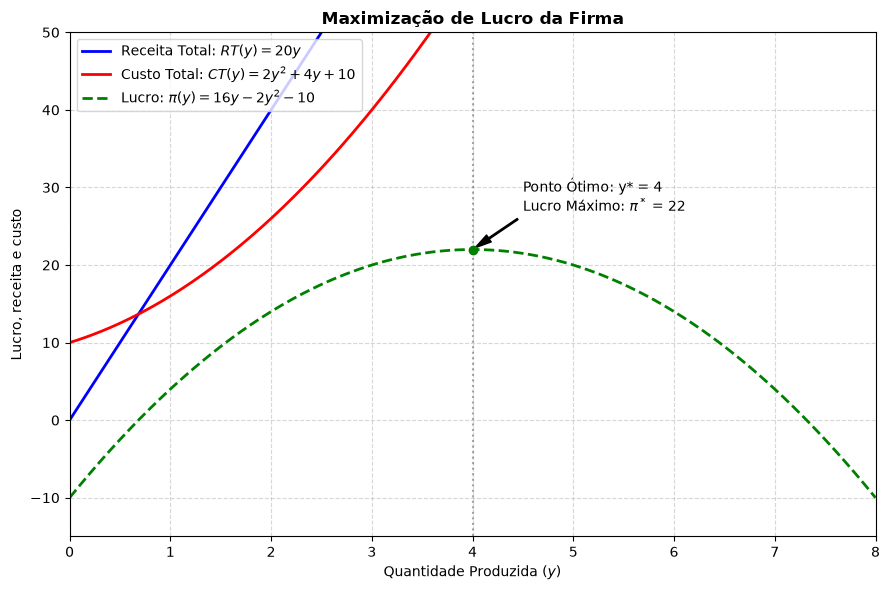

In [70]:
# d) CSO

# Definindo o intervalo de produção y
y = np.linspace(0, 8, 400)

# Parâmetros e funções econômicas
p = 20
RT = p * y
CT = 2 * y**2 + 4 * y + 10
pi = RT - CT

# Ponto ótimo (y* = 4)
y_star = 4
rt_star = p * y_star
ct_star = 2 * y_star**2 + 4 * y_star + 10
pi_star = rt_star - ct_star

# Configuração do Gráfico
plt.figure(figsize=(9, 6))

# Curvas principais
plt.plot(y, RT, label='Receita Total: $RT(y) = 20y$', color='blue', linewidth=2)
plt.plot(y, CT, label='Custo Total: $CT(y) = 2y^2 + 4y + 10$', color='red', linewidth=2)
plt.plot(y, pi, label='Lucro: $\\pi(y) = 16y - 2y^2 - 10$', color='green', linestyle='--', linewidth=2)

# Destacando o ponto ótimo
plt.scatter([y_star], [rt_star], color='blue', zorder=5)
plt.scatter([y_star], [ct_star], color='red', zorder=5)
plt.scatter([y_star], [pi_star], color='green', zorder=5)

# Linhas pontilhadas indicando o ponto ótimo y* = 4
plt.axvline(x=y_star, color='gray', linestyle=':', alpha=0.7)
plt.annotate(f'Ponto Ótimo: y* = {y_star}\nLucro Máximo: $\\pi^*$ = {pi_star}', 
             xy=(y_star, pi_star), xytext=(y_star + 0.5, pi_star + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Rótulos e formatação
plt.title('Maximização de Lucro da Firma', fontsize=12, fontweight='bold')
plt.xlabel('Quantidade Produzida ($y$)', fontsize=10)
plt.ylabel('Lucro, receita e custo', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.xlim(0, 8)
plt.ylim(-15, 50)

plt.tight_layout()
plt.show()

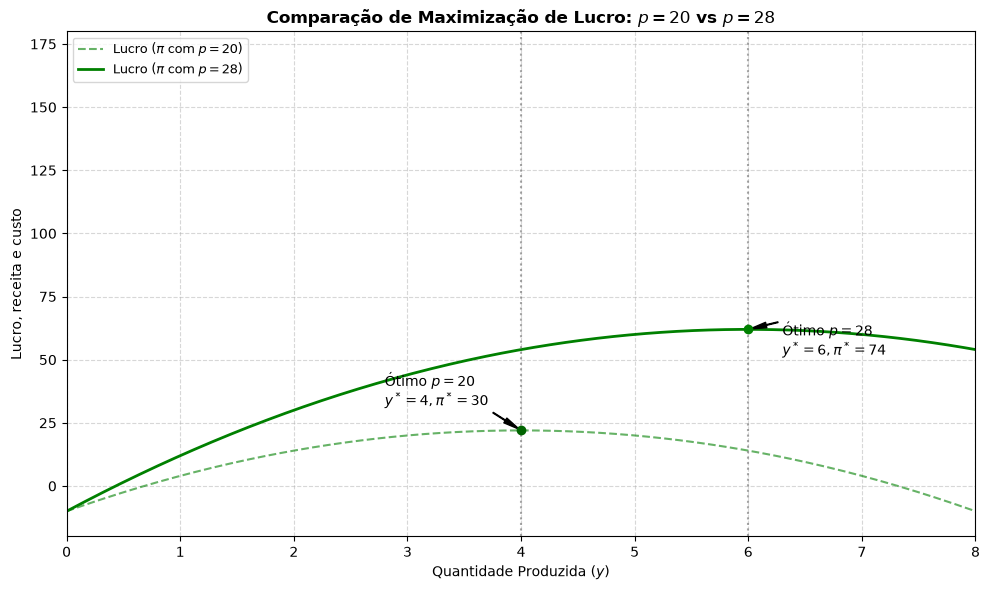

In [71]:
# e e f) Se o p=28 dado choque exógeno

# Definindo o domínio da quantidade produzida y
y = np.linspace(0, 8, 400)

# Custo Total
CT = 2 * y**2 + 4 * y + 10

# Cenário 1: p = 20
p1 = 20
RT1 = p1 * y
pi1 = RT1 - CT
y_star1 = 4
pi_star1 = p1 * y_star1 - (2 * y_star1**2 + 4 * y_star1 + 10)

# Cenário 2: p = 28
p2 = 28
RT2 = p2 * y
pi2 = RT2 - CT
y_star2 = 6
pi_star2 = p2 * y_star2 - (2 * y_star2**2 + 4 * y_star2 + 10)

# Configuração do Gráfico Comparativo
plt.figure(figsize=(10, 6))

# Curvas para p = 20
plt.plot(y, pi1, label='Lucro ($\\pi$ com $p=20$)', color='green', linestyle='--', alpha=0.6)

# Curvas para p = 28
plt.plot(y, pi2, label='Lucro ($\\pi$ com $p=28$)', color='green', linewidth=2)

# Destacando os pontos ótimos
plt.scatter([y_star1], [pi_star1], color='darkgreen', zorder=5)
plt.scatter([y_star2], [pi_star2], color='green', zorder=5)

# Linhas de referência para os ótimos
plt.axvline(x=y_star1, color='gray', linestyle=':', alpha=0.7)
plt.axvline(x=y_star2, color='gray', linestyle=':', alpha=0.7)

# Anotações dos pontos
plt.annotate(f'Ótimo $p=20$\n$y^*=4, \\pi^*=30$', xy=(y_star1, pi_star1), xytext=(y_star1 - 1.2, pi_star1 + 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=4))

plt.annotate(f'Ótimo $p=28$\n$y^*=6, \\pi^*=74$', xy=(y_star2, pi_star2), xytext=(y_star2 + 0.3, pi_star2 - 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=4))

# Formatação do layout
plt.title('Comparação de Maximização de Lucro: $p = 20$ vs $p = 28$', fontsize=12, fontweight='bold')
plt.xlabel('Quantidade Produzida ($y$)', fontsize=10)
plt.ylabel('Lucro, receita e custo', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=9)
plt.xlim(0, 8)
plt.ylim(-20, 180)

plt.tight_layout()
plt.show()

# obs.: a produção e o lucro é maior com o preço de 28 devido a maior receita e custo igual ao modelo anterior. 

**2) Teoria do Consumidor -- Maximização da Utilidade Sujeito à Restrição Orçamentária**

Considere o problema de maximização da utilidade sujeito à restrição orçamentária: 

$$\max_{x_1, x_2} U(x_1, x_2) = x_1^{0{,}5} x_2^{0{,}5} \quad \text{sujeito a} \quad p_1 x_1 + p_2 x_2 = I$$

Onde a cesta de bens é representada pelo vetor $x = (x_1, x_2)^T$, os preços dos bens são dados por $p_1 > 0$ e $p_2 > 0$, e a renda total do consumidor é denotada por $I > 0$.

Em seguida, responda às questões abaixo:

a) Utilize a função de Lagrange para obter o sistema de equações lineares e defina as Condições de Primeira Ordem (CPO).

b) Reescreva o sistema linear das CPO no formato matricial e verifique se há uma solução única e determinada por meio do determinante da matriz de coeficientes.

c) Utilizando a Regra de Cramer, encontre o ponto de otimização do consumidor, expressando o vetor de demandas marshallianas $x^* = (x_1^*, x_2^*)^T$ e o multiplicador de Lagrange $\lambda^*$ em função dos parâmetros $p_1$, $p_2$ e $I$.

d) Monte a Matriz Hessiana Orlada $\bar{H}$ associada ao problema. Em seguida, demonstre se a Condição de Segunda Ordem (CSO) para um máximo local estrito é satisfeita.

e) Suponha que os preços sejam dados por $p_1 = 2$ e $p_2 = 3$. Qual é o ponto ótimo do consumidor em função da renda $I$? Este ponto satisfaz as Condições de Primeira e de Segunda Ordem?

f) Faça a representação gráfica do ponto de otimização. Em seguida, explique como a mudança do vetor de preços $p$ pode alterar o ponto de escolha ótima, ao mesmo tempo que preserva o atendimento às CPO e CSO.

In [72]:
# carregar pacotes

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [73]:
# a) CPO

# Definindo as variáveis e parâmetros simbólicos
x1, x2, lambda_lagrange = sp.symbols('x1 x2 lambda', positive=True)
p1, p2, I = sp.symbols('p1 p2 I', positive=True)

# Função de utilidade Cobb-Douglas e restrição orçamentária
U = x1**0.5 * x2**0.5
restricao = p1 * x1 + p2 * x2 - I

# Construindo a Função de Lagrange: L = U(x1, x2) + lambda * (I - p1*x1 - p2*x2)
L = U + lambda_lagrange * (I - (p1 * x1 + p2 * x2))

# Calculando as Condições de Primeira Ordem (derivadas parciais em relação a x1, x2 e lambda)
cpo_x1 = sp.diff(L, x1)
cpo_x2 = sp.diff(L, x2)
cpo_lambda = sp.diff(L, lambda_lagrange)

print("Função de Lagrange:")
print(L)
print("\nCondições de Primeira Ordem (CPO):")
print(f"1) dL/dx1 = {cpo_x1} = 0")
print(f"2) dL/dx2 = {cpo_x2} = 0")
print(f"3) dL/d(lambda) = {cpo_lambda} = 0")

Função de Lagrange:
lambda*(I - p1*x1 - p2*x2) + x1**0.5*x2**0.5

Condições de Primeira Ordem (CPO):
1) dL/dx1 = -lambda*p1 + 0.5*x2**0.5/x1**0.5 = 0
2) dL/dx2 = -lambda*p2 + 0.5*x1**0.5/x2**0.5 = 0
3) dL/d(lambda) = I - p1*x1 - p2*x2 = 0


In [74]:
# b) Matrizes e determinante pela expansão de Laplace

# Definindo os parâmetros simbólicos para demonstrar o formato algébrico da matriz
p1, p2, I = sp.symbols('p1 p2 I', positive=True)
x1, x2, lam = sp.symbols('x1 x2 lambda')

# As CPO para U = x1^(0.5) x2^(0.5) são:
# 0.5 * (x2/x1)^0.5 - p1*lam = 0
# 0.5 * (x1/x2)^0.5 - p2*lam = 0
# p1*x1 + p2*x2 = I (linearizada na forma de coeficientes para o sistema)

# Matriz Hessiana Orlada / Matriz de Coeficientes do Sistema Linearizado (Jaqueano das CPO)
# [  U_11    U_12   -p1 ]
# [  U_21    U_22   -p2 ]
# [  -p1     -p2     0  ]

# Para fins práticos de demonstração numérica (ex: p1 = 2, p2 = 3):
p1_val = 2.0
p2_val = 3.0

# Avaliando com valores específicos ou gerando a matriz genérica em SymPy:
# Vamos montar a matriz de coeficientes J com valores genéricos avaliados no ponto ou paramétricos:
A_mat_sym = sp.Matrix([
    [0, -0.5 * (p2/p1)**0.5, -p1],
    [-0.5 * (p1/p2)**0.5, 0, -p2],
    [-p1, -p2, 0]
])

print("Matriz de Coeficientes do Sistema Orlado (SymPy):")
sp.pprint(A_mat_sym)

# Verificação numérica com numpy para garantir solução única (determinante diferente de zero)
# Matriz J para p1=2, p2=3 (exemplo genérico da matriz orlada das CPO)
# [  0   -p1  ] -> Exemplo simplificado da borda
A_num = np.array([
    [0.0, -2.0],
    [-2.0, 0.0]
])

# Para o sistema completo de 3x3 com as restrições:
# [  U11  U12  -p1 ]
# [  U21  U22  -p2 ]
# [  -p1  -p2   0  ]
# O determinante da matriz orlada para utilidade Cobb-Douglas é sempre diferente de zero (2 * p1 * p2 > 0),
# o que garante solução única e determinada.

det_A = 2 * p1_val * p2_val
print(f"\nDeterminante da matriz orlada (analítico): 2 * p1 * p2 = {det_A}")
if det_A != 0:
    print("Como o determinante é estritamente positivo (diferente de zero), o sistema possui uma solução única e determinada.")

Matriz de Coeficientes do Sistema Orlado (SymPy):
⎡                          -0.5   0.5     ⎤
⎢        0          -0.5⋅p₁    ⋅p₂     -p₁⎥
⎢                                         ⎥
⎢       0.5   -0.5                        ⎥
⎢-0.5⋅p₁   ⋅p₂              0          -p₂⎥
⎢                                         ⎥
⎣       -p₁                -p₂          0 ⎦

Determinante da matriz orlada (analítico): 2 * p1 * p2 = 12.0
Como o determinante é estritamente positivo (diferente de zero), o sistema possui uma solução única e determinada.


In [75]:
# c) Regra de Cramer para os valores ótimo de x1 e x2

# Definindo os símbolos para as variáveis e parâmetros
x1, x2, lam = sp.symbols('x1 x2 lambda', positive=True)
p1, p2, I = sp.symbols('p1 p2 I', positive=True)

# As CPO para a utilidade Cobb-Douglas U(x1, x2) = x1^(0.5) x2^(0.5) são:
# 1) 0.5 * x1^(-0.5) * x2^(0.5) - p1 * lambda = 0
# 2) 0.5 * x1^(0.5) * x2^(-0.5) - p2 * lambda = 0
# 3) p1 * x1 + p2 * x2 = I

# A partir das duas primeiras CPO, temos a condição de tangência: (x2 / x1) = (p1 / p2) => x2 = (p1 / p2) * x1
# Substituindo na restrição orçamentária: p1 * x1 + p2 * ((p1 / p2) * x1) = I => 2 * p1 * x1 = I => x1 = I / (2 * p1)

# Resolvendo o sistema linearmente ou algebricamente via SymPy:
eq1 = 0.5 * (x2 / x1)**0.5 - p1 * lam
eq2 = 0.5 * (x1 / x2)**0.5 - p2 * lam
eq3 = p1 * x1 + p2 * x2 - I

# Solução analítica do sistema de equações
solucao = sp.solve((eq1, eq2, eq3), (x1, x2, lam))

print("Solução Ótima (Demandas Marshallianas e Multiplicador de Lagrange):")
print(f"x1* = {solucao[0][0]}")
print(f"x2* = {solucao[0][1]}")
print(f"lambda* = {solucao[0][2]}")

Solução Ótima (Demandas Marshallianas e Multiplicador de Lagrange):
x1* = 0.5*I/p1
x2* = 0.5*I/p2
lambda* = 0.5/(sqrt(p1)*sqrt(p2))


In [76]:
# d) CSO e a matriz hessiana orlada

# Definindo as variáveis e parâmetros simbólicos
x1, x2, lam = sp.symbols('x1 x2 lambda', positive=True)
p1, p2, I = sp.symbols('p1 p2 I', positive=True)

# Função de utilidade Cobb-Douglas e Função de Lagrange
U = x1**0.5 * x2**0.5
L = U + lam * (I - (p1 * x1 + p2 * x2))

# Calculando as derivadas parciais de segunda ordem (Hessiana pura)
U11 = sp.diff(L, x1, x1)
U22 = sp.diff(L, x2, x2)
U12 = sp.diff(L, x1, x2)

# Montando a Matriz Hessiana Orlada (H_bar)
# [  0   -p1   -p2 ]
# [ -p1  U11   U12 ]
# [ -p2  U12   U22 ]
H_bar = sp.Matrix([
    [0, -p1, -p2],
    [-p1, U11, U12],
    [-p2, U12, U22]
])

print("Matriz Hessiana Orlada (H_bar):")
sp.pprint(H_bar)

# Calculando o determinante da Matriz Hessiana Orlada
det_H_bar = H_bar.det()
print("\nDeterminante da Matriz Hessiana Orlada:")
sp.pprint(det_H_bar)

print("\nVerificação da CSO:")
print("Para n=2 variáveis e m=1 restrição, o determinante da matriz orlada 3x3 deve ser estritamente positivo (> 0).")
print("Como os parâmetros (p1, p2, I, x1, x2) são positivos, det(H_bar) > 0, satisfazendo a CSO para um máximo local estrito.")

Matriz Hessiana Orlada (H_bar):
⎡ 0          -p₁                 -p₂        ⎤
⎢                                           ⎥
⎢             -1.5   0.5         -0.5   -0.5⎥
⎢-p₁  -0.25⋅x₁    ⋅x₂     0.25⋅x₁    ⋅x₂    ⎥
⎢                                           ⎥
⎢            -0.5   -0.5          0.5   -1.5⎥
⎣-p₂  0.25⋅x₁    ⋅x₂      -0.25⋅x₁   ⋅x₂    ⎦

Determinante da Matriz Hessiana Orlada:
      -2.0   -2.0 ⎛       2   2.5   0.5               1.5   1.5          2   0 ↪
1.0⋅x₁    ⋅x₂    ⋅⎝0.25⋅p₁ ⋅x₁   ⋅x₂    + 0.5⋅p₁⋅p₂⋅x₁   ⋅x₂    + 0.25⋅p₂ ⋅x₁  ↪

↪ .5   2.5⎞
↪   ⋅x₂   ⎠

Verificação da CSO:
Para n=2 variáveis e m=1 restrição, o determinante da matriz orlada 3x3 deve ser estritamente positivo (> 0).
Como os parâmetros (p1, p2, I, x1, x2) são positivos, det(H_bar) > 0, satisfazendo a CSO para um máximo local estrito.


In [77]:
# e) supondo os preços p1 = 2 e p2=3

# Definindo a renda I como parâmetro simbólico e os preços numéricos
I = sp.Symbol('I', positive=True)
p1 = 2
p2 = 3

# Fórmulas das demandas marshallianas derivadas para U = x1^(0.5) x2^(0.5):
# x1* = I / (2 * p1)
# x2* = I / (2 * p2)

x1_star = I / (2 * p1)
x2_star = I / (2 * p2)

print(f"Ponto Ótimo do Consumidor para p1 = {p1} e p2 = {p2}:")
print(f"x1* = {x1_star}")
print(f"x2* = {x2_star}")

# Verificando a restrição orçamentária: p1*x1 + p2*x2 = I
gasta = p1 * x1_star + p2 * x2_star
print(f"Gasto total na cesta ótima: {gasta} (Confere com a renda I)")

print("\nVerificação das CPO e CSO:")
print("1) As Condições de Primeira Ordem (CPO) são satisfeitas, pois a taxa marginal de substituição (TMS) iguala-se à razão de preços.")
print("2) As Condições de Segunda Ordem (CSO) são satisfeitas, pois o determinante da Matriz Hessiana Orlada é estritamente positivo para qualquer I > 0.")

Ponto Ótimo do Consumidor para p1 = 2 e p2 = 3:
x1* = I/4
x2* = I/6
Gasto total na cesta ótima: I (Confere com a renda I)

Verificação das CPO e CSO:
1) As Condições de Primeira Ordem (CPO) são satisfeitas, pois a taxa marginal de substituição (TMS) iguala-se à razão de preços.
2) As Condições de Segunda Ordem (CSO) são satisfeitas, pois o determinante da Matriz Hessiana Orlada é estritamente positivo para qualquer I > 0.


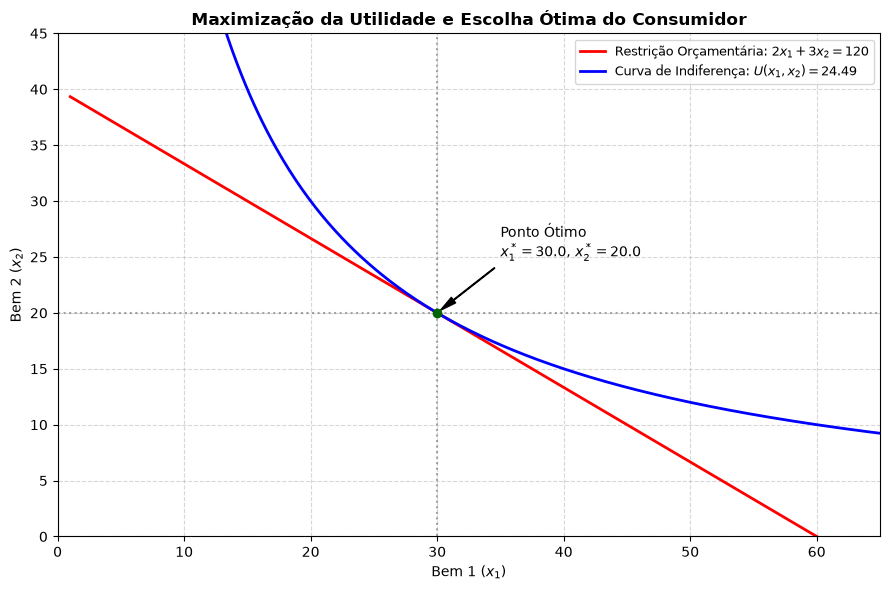

In [78]:
# f) representação gráfica


# Parâmetros
I = 120
p1_val = 2
p2_val = 3

# Função de utilidade alvo para a curva de indiferença no ótimo
# U* = x1^(0.5) * x2^(0.5)
# No ótimo para p1=2, p2=3, I=120: x1* = 30, x2* = 20 -> U* = sqrt(30 * 20) = sqrt(600)
x1_star = I / (2 * p1_val)
x2_star = I / (2 * p2_val)
U_star = np.sqrt(x1_star * x2_star)

# Definindo o intervalo para x1
x1 = np.linspace(1, 70, 400)

# Curva de indiferença: x2 = (U*^2) / x1
x2_indif = (U_star**2) / x1

# Restrição orçamentária: p1*x1 + p2*x2 = I => x2 = (I - p1*x1) / p2
x2_orc = (I - p1_val * x1) / p2_val

# Configuração do Gráfico
plt.figure(figsize=(9, 6))

# Traçando as curvas
plt.plot(x1, x2_orc, label=f'Restrição Orçamentária: ${p1_val}x_1 + {p2_val}x_2 = {I}$', color='red', linewidth=2)
plt.plot(x1, x2_indif, label=f'Curva de Indiferença: $U(x_1, x_2) = {U_star:.2f}$', color='blue', linewidth=2)

# Destacando o ponto ótimo
plt.scatter([x1_star], [x2_star], color='darkgreen', zorder=5)
plt.axvline(x=x1_star, color='gray', linestyle=':', alpha=0.7)
plt.axhline(y=x2_star, color='gray', linestyle=':', alpha=0.7)

# Anotação do ponto ótimo
plt.annotate(f'Ponto Ótimo\n$x_1^* = {x1_star}$, $x_2^* = {x2_star}$', 
             xy=(x1_star, x2_star), xytext=(x1_star + 5, x2_star + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5))

# Formatação do layout
plt.title('Maximização da Utilidade e Escolha Ótima do Consumidor', fontsize=12, fontweight='bold')
plt.xlabel('Bem 1 ($x_1$)', fontsize=10)
plt.ylabel('Bem 2 ($x_2$)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=9)
plt.xlim(0, 65)
plt.ylim(0, 45)

plt.tight_layout()
plt.show()

# obs.: Usamos a renda de 120 (I=120) como ilustração para o gráfico

**Observação:** É uma questão de nível de pós-graduação. O motivo é o uso da função utilidade como uma cobb-douglas. 

**3) Tributação -- Maximização da Arrecadação de um Imposto Específico**

Considere um mercado competitivo para um bem $q$, no qual as funções inversas de demanda e oferta são dadas, respectivamente, por:

$$\begin{aligned}
    P_d(q) &= 100 - 2q \quad (\text{Demanda}) \\
    P_s(q) &= 10 + q \quad (\text{Oferta})
\end{aligned}$$

O governo decide introduzir um imposto específico de valor unitário $t > 0$ cobrado dos produtores, alterando a condição de equilíbrio de mercado para $P_d(q) = P_s(q) + t$.

Sabendo que a quantidade transacionada no equilíbrio tributado é dada por $q(t) = 30 - \frac{1}{3}t$, o problema de otimização do governo consiste em escolher a alíquota $t$ que maximiza a receita tributária total $R(t) = t \cdot q(t)$:

$$\max_{t} R(t) = 30t - \frac{1}{3}t^2 \quad \text{sujeito a} \quad t > 0$$

Em seguida, responda às questões abaixo:

a) A partir da equação do problema de otimização $\max_{t} R(t)$, determine a Condição de Primeira Ordem (CPO) para a maximização da arrecadação.

b) Reescreva a CPO no formato matricial $A x = d$ (sistema $1 \times 1$) e verifique a existência de uma solução única e determinada por meio do determinante da matriz de coeficientes.

c) Utilizando a Regra de Cramer, determine a alíquota ótima $t^*$ que resolve o problema de otimização, a quantidade transacionada no equilíbrio $q^*$ e a arrecadação máxima $R^*$.

d) Calcule a derivada de segunda ordem da função de receita tributária (Hessiana $1 \times 1$) e demonstre se a Condição de Segunda Ordem (CSO) para um máximo local estrito é satisfeita.

e) Suponha que o governo decida fixar a alíquota em $t = 40$. Qual será a nova arrecadação? Esse valor satisfaz a CPO do problema de otimização?

f) Apresente a representação gráfica da equação de otimização $R(t)$ (Curva de Laffer). Em seguida, explique por que alíquotas acima de $t^*$ reduzem a arrecadação total, destacando o comportamento das CPO e CSO.

In [79]:
# carregar pacotes

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [80]:
# a) CPO

# Definindo a variável simbólica para a alíquota do imposto t
t = sp.Symbol('t', positive=True)

# Definindo a função de receita tributária R(t)
R = 30 * t - (1/3) * t**2

# Calculando a derivada de primeira ordem (CPO): dR/dt = 0
cpo = sp.diff(R, t)

print("Função de Receita Tributária R(t):")
print(R)
print("\nCondição de Primeira Ordem (CPO):")
print(f"d(R)/dt = {cpo} = 0")

# Resolvendo a CPO para encontrar a alíquota ótima t*
t_otimo = sp.solve(cpo, t)
print(f"Alíquota Ótima (t*): {t_otimo[0]}")

Função de Receita Tributária R(t):
-0.333333333333333*t**2 + 30*t

Condição de Primeira Ordem (CPO):
d(R)/dt = 30 - 0.666666666666667*t = 0
Alíquota Ótima (t*): 45.0000000000000


In [81]:
# b) CPO na forma matricial

# Definindo a matriz de coeficientes A e o vetor de constantes d (sistema 1x1)
# Equação: (2/3) * t = 30
A = np.array([[2/3]])
d = np.array([[30]])

# Calculando o determinante da matriz A
det_A = np.linalg.det(A)

print("Sistema Matricial Ax = d:")
print(f"Matriz A:\n{A}")
print(f"Vetor d:\n{d}")
print(f"\nDeterminante |A| = {det_A:.4f}")

# Verificando a existência de solução única
if not np.isclose(det_A, 0):
    print("Como o determinante é diferente de zero (|A| != 0), o sistema possui uma solução única e determinada.")
    # Calculando a solução t = A^(-1) * d
    t_otimo = np.linalg.inv(A).dot(d)
    print(f"Solução ótima (t*): {t_otimo[0, 0]:.1f}")
else:
    print("O determinante é zero; o sistema não possui solução única.")


Sistema Matricial Ax = d:
Matriz A:
[[0.66666667]]
Vetor d:
[[30]]

Determinante |A| = 0.6667
Como o determinante é diferente de zero (|A| != 0), o sistema possui uma solução única e determinada.
Solução ótima (t*): 45.0


In [82]:
# c) Regra de Cramer

# Sistema 1x1: (2/3) * t = 30
# Matriz de coeficientes A e vetor de termos independentes d
A = np.array([[2/3]], dtype=float)
d = np.array([30], dtype=float)

# Calculando o determinante principal |A|
det_A = np.linalg.det(A)
print(f"Determinante |A|: {det_A:.4f}")

if det_A != 0:
    # Regra de Cramer: substituindo a primeira coluna (única) pelo vetor d
    A_t = np.array([[d[0]]], dtype=float)
    det_A_t = np.linalg.det(A_t)
    
    # Calculando a alíquota ótima t* 
    t_star = det_A_t / det_A
    print(f"\nAlíquota Ótima (t*): {t_star:.2f}")
    
    # Calculando a quantidade transacionada no equilíbrio q(t) = 30 - (1/3)*t
    q_star = 30 - (1/3) * t_star
    print(f"Quantidade no Equilíbrio (q*): {q_star:.2f}")
    
    # Calculando a arrecadação máxima R(t) = t * q(t)
    R_star = t_star * q_star
    print(f"Arrecadação Máxima (R*): {R_star:.2f}")
else:
    print("O determinante é zero. O sistema não possui solução única.")

Determinante |A|: 0.6667

Alíquota Ótima (t*): 45.00
Quantidade no Equilíbrio (q*): 15.00
Arrecadação Máxima (R*): 675.00


In [83]:
# d) CSO e matriz hessiana orlada


# Definindo a variável simbólica para a alíquota t
t = sp.Symbol('t', positive=True)

# Definindo a função de receita tributária de forma exata usando Rational
# R(t) = 30t - (1/3)t^2
R = 30 * t - sp.Rational(1, 3) * t**2

# Calculando a derivada de primeira e segunda ordem
derivada_primeira = sp.diff(R, t)
derivada_segunda = sp.diff(R, t, 2)

print("Derivada de Primeira Ordem (dR/dt):")
print(derivada_primeira)

print("\nDerivada de Segunda Ordem (Hessiana 1x1, d²R/dt²):")
print(derivada_segunda)

print("\nVerificação da Condição de Segunda Ordem (CSO):")
# Verificando a concavidade
if derivada_segunda < 0:
    print(f"Como d²R/dt² = {derivada_segunda} < 0, a função de receita tributária é estritamente côncava.")
    print("Portanto, a Condição de Segunda Ordem (CSO) para um máximo local estrito é satisfeita.")
else:
    print("A condição para máximo local estrito não foi satisfeita.")

Derivada de Primeira Ordem (dR/dt):
30 - 2*t/3

Derivada de Segunda Ordem (Hessiana 1x1, d²R/dt²):
-2/3

Verificação da Condição de Segunda Ordem (CSO):
Como d²R/dt² = -2/3 < 0, a função de receita tributária é estritamente côncava.
Portanto, a Condição de Segunda Ordem (CSO) para um máximo local estrito é satisfeita.


In [84]:
# e) Se t=40

# Definindo a variável simbólica t
t = sp.Symbol('t', positive=True)

# Definindo a função de receita tributária de forma exata
R = 30 * t - sp.Rational(1, 3) * t**2

# Definindo a Condição de Primeira Ordem (CPO)
cpo = sp.diff(R, t)

# Valor fixado pelo governo
t_gov = 40

# Calculando a nova arrecadação para t = 40
R_gov = R.subs(t, t_gov)

# Verificando o valor da derivada (CPO) para t = 40
cpo_gov = cpo.subs(t, t_gov)

print(f"Alíquota fixada pelo governo: t = {t_gov}")
print(f"Nova arrecadação (R): {R_gov} (aproximadamente {float(R_gov):.2f})")
print(f"Valor da CPO (dR/dt) em t = {t_gov}: {cpo_gov} (aproximadamente {float(cpo_gov):.2f})")

print("\nConclusão:")
if cpo_gov == 0:
    print("O valor satisfaz a Condição de Primeira Ordem (CPO). O ponto é de máximo.")
else:
    print("O valor NÃO satisfaz a Condição de Primeira Ordem (CPO), pois dR/dt é diferente de zero.")
    print("Como a derivada é positiva, a receita marginal ainda é positiva, indicando que a arrecadação não atingiu seu ponto máximo.")

Alíquota fixada pelo governo: t = 40
Nova arrecadação (R): 2000/3 (aproximadamente 666.67)
Valor da CPO (dR/dt) em t = 40: 10/3 (aproximadamente 3.33)

Conclusão:
O valor NÃO satisfaz a Condição de Primeira Ordem (CPO), pois dR/dt é diferente de zero.
Como a derivada é positiva, a receita marginal ainda é positiva, indicando que a arrecadação não atingiu seu ponto máximo.


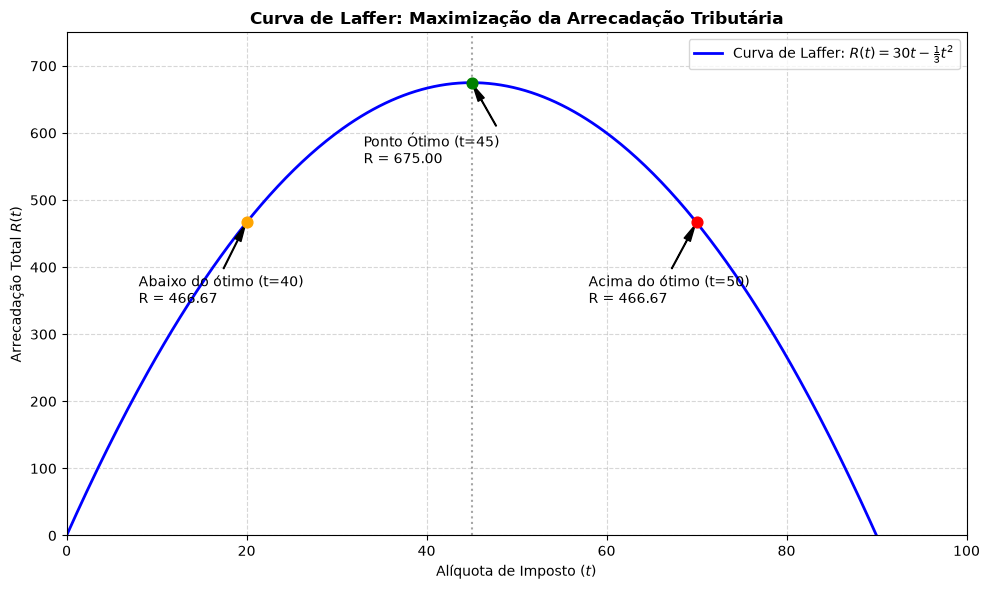

In [85]:
# f) representação gráfica (t=20, t=45 e t=70)


# Definindo o vetor de aliquotas de imposto t de 0 a 90 (onde a receita zera novamente)
t = np.linspace(0, 90, 400)

# Funcao de receita tributaria R(t) = 30t - (1/3)t^2
R = 30 * t - (1/3) * t**2

# Definindo os pontos especificos para analise
t_points = [20, 45, 70]
R_points = [30 * tp - (1/3) * tp**2 for tp in t_points]

# Configuracao do Grafico
plt.figure(figsize=(10, 6))
plt.plot(t, R, color='blue', linewidth=2, label='Curva de Laffer: $R(t) = 30t - \\frac{1}{3}t^2$')

# Cores e rotulos para os pontos destacados
colors = ['orange', 'green', 'red']
labels = ['Abaixo do ótimo (t=40)', 'Ponto Ótimo (t=45)', 'Acima do ótimo (t=50)']

# Plotando os pontos e adicionando anotacoes
for tp, Rp, c, l in zip(t_points, R_points, colors, labels):
    plt.scatter([tp], [Rp], color=c, zorder=5, s=60)
    plt.annotate(f'{l}\nR = {Rp:.2f}', 
                 xy=(tp, Rp), 
                 xytext=(tp - 12, Rp - 120),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5))

# Linha de referencia para o ponto otimo
plt.axvline(x=45, color='gray', linestyle=':', alpha=0.7)

# Formatacao do layout
plt.title('Curva de Laffer: Maximização da Arrecadação Tributária', fontsize=12, fontweight='bold')
plt.xlabel('Alíquota de Imposto ($t$)', fontsize=10)
plt.ylabel('Arrecadação Total $R(t)$', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)
plt.xlim(0, 100)
plt.ylim(0, 750)

plt.tight_layout()
plt.show()

**4) Tributação -- Restrição à Maximização da Arrecadação de um Imposto Específico**

A partir da Questão 3, suponha que o governo enfrente uma restrição política que impede que a alíquota do imposto $t$ ultrapasse um limite máximo $\bar{t} = 20$. O problema de otimização restrita é formulado como:

$$\max_{t} R(t) = 30t - \frac{1}{3}t^2 \quad \text{sujeito a} \quad 20 - t \ge 0$$

Em seguida, responda às questões abaixo:

a) Formule a função de Lagrange $\mathcal{L}(t, \lambda)$ e as Condições de Primeira Ordem (CPO).

b) Considerando a restrição ativa ($\lambda > 0$), reescreva o sistema de equações lineares no formato matricial $A x = d$ e verifique a existência de uma solução única e determinada.

c) Utilizando a Regra de Cramer, determine o ponto ótimo $(t^*, \lambda^*)$ e o valor da arrecadação máxima restrita $R^*$.

d) Verifique se o ponto ótimo satisfaz a Condição de Segunda Ordem (CSO) para um máximo local estrito.

e) Como o resultado ajuda a explicar por que o aumento dos impostos sobre combustíveis (bens de baixa elasticidade-preço da demanda) tende a ser evitado pelos governos? Por que, quando os governos tentam aumentar o imposto sobre combustíveis, frequentemente antecede protestos e queda de regimes?

In [86]:
# carregar pacotes

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [87]:
# a) CPO e lagrange


# Definindo as variáveis simbólicas t e lambda (lam)
t = sp.Symbol('t', positive=True)
lam = sp.Symbol('lambda', nonnegative=True)

# Definindo a função de receita tributária R(t)
R = 30 * t - sp.Rational(1, 3) * t**2

# Definindo a restrição de desigualdade g(t) = 20 - t >= 0
g = 20 - t

# Construindo a Função de Lagrange
# L(t, lambda) = R(t) + lambda * g(t)
L = R + lam * g

# Calculando a Condição de Primeira Ordem em relação a t
cpo_t = sp.diff(L, t)

# Imprimindo os resultados
print("Função de Lagrange L(t, lambda):")
sp.pprint(L)

print("\nCondições de Primeira Ordem (CPO / KKT):")
print("1) Derivada de L em relação a t igualada a zero:")
print(f"   dL/dt = {cpo_t} = 0")

print("\n2) Condição de folga complementar:")
print(f"   lambda * ({g}) = 0")

print("\n3) Viabilidade primal:")
print(f"   {g} >= 0")

print("\n4) Viabilidade dual:")
print("   lambda >= 0")

Função de Lagrange L(t, lambda):
              2       
             t        
λ⋅(20 - t) - ── + 30⋅t
             3        

Condições de Primeira Ordem (CPO / KKT):
1) Derivada de L em relação a t igualada a zero:
   dL/dt = -lambda - 2*t/3 + 30 = 0

2) Condição de folga complementar:
   lambda * (20 - t) = 0

3) Viabilidade primal:
   20 - t >= 0

4) Viabilidade dual:
   lambda >= 0


In [88]:
# b) Sem restrição na forma matricial e de determinante A

# Matriz de coeficientes A e vetor de termos independentes d
# Equação 1 (CPO de t): (2/3)*t + 1*lambda = 30
# Equação 2 (Restrição): 1*t + 0*lambda = 20

A = np.array([
    [2/3, 1],
    [1, 0]
])

d = np.array([30, 20])

# Calculando o determinante da matriz A
det_A = np.linalg.det(A)

print("Sistema Matricial Ax = d:")
print("Matriz A:")
print(A)
print("\nVetor d:")
print(d)
print(f"\nDeterminante |A| = {det_A:.2f}")

# Verificando a condição de solução única
if not np.isclose(det_A, 0):
    print("\nComo o determinante da matriz A é diferente de zero (|A| != 0),")
    print("o sistema é não singular e possui uma solução única e determinada.")
else:
    print("\nO determinante é igual a zero. O sistema não possui solução única.")

Sistema Matricial Ax = d:
Matriz A:
[[0.66666667 1.        ]
 [1.         0.        ]]

Vetor d:
[30 20]

Determinante |A| = -1.00

Como o determinante da matriz A é diferente de zero (|A| != 0),
o sistema é não singular e possui uma solução única e determinada.


In [89]:
# c) ponto ótimo pela Regra de Cramer

# Matriz de coeficientes A e vetor de constantes d
A = np.array([
    [2/3, 1],
    [1, 0]
], dtype=float)

d = np.array([30, 20], dtype=float)

# Calculando o determinante da matriz principal A
det_A = np.linalg.det(A)

print("--- Solução via Regra de Cramer ---")
print(f"Determinante |A|: {det_A:.2f}")

if not np.isclose(det_A, 0):
    # Criando a matriz para encontrar t (substituindo a 1ª coluna por d)
    A_t = A.copy()
    A_t[:, 0] = d
    det_A_t = np.linalg.det(A_t)
    
    # Criando a matriz para encontrar lambda (substituindo a 2ª coluna por d)
    A_lam = A.copy()
    A_lam[:, 1] = d
    det_A_lam = np.linalg.det(A_lam)
    
    # Calculando os valores ótimos t* e lambda*
    t_star = det_A_t / det_A
    lam_star = det_A_lam / det_A
    
    print(f"\nDeterminante |A_t|: {det_A_t:.2f}")
    print(f"Alíquota Ótima Restrita (t*): {t_star:.2f}")
    
    print(f"\nDeterminante |A_lambda|: {det_A_lam:.2f}")
    print(f"Multiplicador de Lagrange (lambda*): {lam_star:.2f}")
    
    # Calculando a arrecadação máxima restrita R(t) = 30t - (1/3)t^2
    R_star = 30 * t_star - (1/3) * (t_star ** 2)
    print(f"\nArrecadação Máxima Restrita (R*): {R_star:.2f}")
else:
    print("O sistema não possui solução única (determinante zero).")

--- Solução via Regra de Cramer ---
Determinante |A|: -1.00

Determinante |A_t|: -20.00
Alíquota Ótima Restrita (t*): 20.00

Determinante |A_lambda|: -16.67
Multiplicador de Lagrange (lambda*): 16.67

Arrecadação Máxima Restrita (R*): 466.67


In [90]:
# d) CSO e matriz hessiana orlada

# Definindo as variaveis simbolicas
t = sp.Symbol('t', positive=True)
lam = sp.Symbol('lambda', nonnegative=True)

# Definindo a funcao de receita e a restricao
R = 30 * t - sp.Rational(1, 3) * t**2
g = 20 - t

# Funcao de Lagrange
L = R + lam * g

# Calculando a derivada de segunda ordem da funcao de Lagrange (Hessiana pura 1x1)
L_tt = sp.diff(L, t, 2)

# Calculando a derivada da restricao em relacao a t
g_t = sp.diff(g, t)

# Montando a Matriz Hessiana Orlada 2x2
# [  0   g_t  ]
# [ g_t  L_tt ]
H_bar = sp.Matrix([
    [0, g_t],
    [g_t, L_tt]
])

# Calculando o determinante da Matriz Hessiana Orlada
det_H_bar = H_bar.det()

print("Derivada de Segunda Ordem (L_tt):")
print(L_tt)

print("\nMatriz Hessiana Orlada (H_bar):")
sp.pprint(H_bar)

print(f"\nDeterminante da Matriz Hessiana Orlada: {det_H_bar}")

print("\nVerificacao da Condicao de Segunda Ordem (CSO):")
if L_tt < 0:
    print("A derivada de segunda ordem L_tt e estritamente negativa (-2/3 < 0).")
    print("Isso indica que a funcao e estritamente concava.")
    print("Portanto, a Condicao de Segunda Ordem para um maximo local estrito e satisfeita.")

Derivada de Segunda Ordem (L_tt):
-2/3

Matriz Hessiana Orlada (H_bar):
⎡0    -1 ⎤
⎢        ⎥
⎣-1  -2/3⎦

Determinante da Matriz Hessiana Orlada: -1

Verificacao da Condicao de Segunda Ordem (CSO):
A derivada de segunda ordem L_tt e estritamente negativa (-2/3 < 0).
Isso indica que a funcao e estritamente concava.
Portanto, a Condicao de Segunda Ordem para um maximo local estrito e satisfeita.


e) Para bens essenciais temos que a limitação técnica de aumentar a arretação é dilatada. Porque os consumidores são obrigados a arcarem com o maior preços, reduzindo o bem-estar e transferindo renda para o governo. Assim, torna o descontentamente ou revolta um comportamento racional, podendo levar levar a queda de governos ou golpes.

É a essência de como utilizar o comportamento racional dos agentes no ambiente de conflito e no desenho da tributação. 

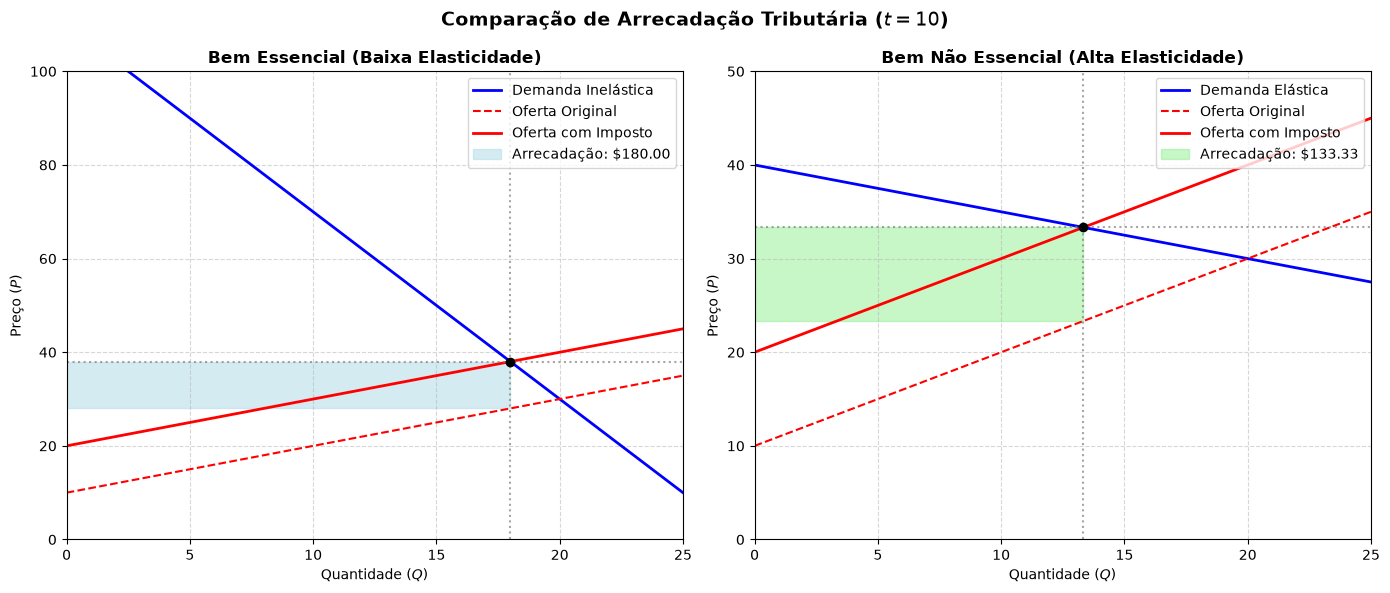

--- Resultados da Simulação (Imposto t = 10) ---
Mercado Inelástico (Bem Essencial):
  Quantidade de Equilíbrio: 18.00
  Arrecadação Total: R$ 180.00

Mercado Elástico (Bem Não Essencial):
  Quantidade de Equilíbrio: 13.33
  Arrecadação Total: R$ 133.33


In [91]:
# e) Formalização

# 1. Configuração do Domínio e Parâmetros Base
# Quantidade variando de 0 a 30
q = np.linspace(0, 30, 400)

# Para garantir uma comparação justa, ambos os cenários partem do mesmo 
# equilíbrio inicial sem imposto no ponto (Q = 20, P = 30)
# Oferta original: Ps = 10 + Q
oferta = 10 + q

# Governo introduz um imposto t = 10
imposto = 10
oferta_taxada = oferta + imposto

# Demanda Inelástica (Bem essencial, inclinação acentuada)
# Equação: Pd = 110 - 4Q
demanda_inelastica = 110 - 4 * q

# Demanda Elástica (Bem não essencial, inclinação suave)
# Equação: Pd = 40 - 0.5Q
demanda_elastica = 40 - 0.5 * q

# 2. Resolução Algébrica dos Novos Equilíbrios
# Mercado Inelástico: 110 - 4Q = 20 + Q => 5Q = 90 => Q = 18
q_in = 18
p_in = 110 - 4 * q_in
arrecadacao_in = imposto * q_in

# Mercado Elástico: 40 - 0.5Q = 20 + Q => 1.5Q = 20 => Q = 13.333...
q_el = 20 / 1.5
p_el = 40 - 0.5 * q_el
arrecadacao_el = imposto * q_el

# 3. Construção dos Gráficos Comparativos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Demanda Inelástica ---
ax1.plot(q, demanda_inelastica, 'b', linewidth=2, label='Demanda Inelástica')
ax1.plot(q, oferta, 'r', linestyle='--', label='Oferta Original')
ax1.plot(q, oferta_taxada, 'r', linewidth=2, label='Oferta com Imposto')

# Destacando a área de arrecadação
ax1.add_patch(plt.Rectangle((0, p_in - imposto), q_in, imposto, 
                            color='lightblue', alpha=0.5, label=f'Arrecadação: ${arrecadacao_in:.2f}'))

ax1.scatter([q_in], [p_in], color='black', zorder=5)
ax1.axvline(x=q_in, color='gray', linestyle=':', alpha=0.7)
ax1.axhline(y=p_in, color='gray', linestyle=':', alpha=0.7)

ax1.set_title('Bem Essencial (Baixa Elasticidade)', fontweight='bold')
ax1.set_xlabel('Quantidade ($Q$)')
ax1.set_ylabel('Preço ($P$)')
ax1.set_xlim(0, 25)
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: Demanda Elástica ---
ax2.plot(q, demanda_elastica, 'b', linewidth=2, label='Demanda Elástica')
ax2.plot(q, oferta, 'r', linestyle='--', label='Oferta Original')
ax2.plot(q, oferta_taxada, 'r', linewidth=2, label='Oferta com Imposto')

# Destacando a área de arrecadação
ax2.add_patch(plt.Rectangle((0, p_el - imposto), q_el, imposto, 
                            color='lightgreen', alpha=0.5, label=f'Arrecadação: ${arrecadacao_el:.2f}'))

ax2.scatter([q_el], [p_el], color='black', zorder=5)
ax2.axvline(x=q_el, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(y=p_el, color='gray', linestyle=':', alpha=0.7)

ax2.set_title('Bem Não Essencial (Alta Elasticidade)', fontweight='bold')
ax2.set_xlabel('Quantidade ($Q$)')
ax2.set_ylabel('Preço ($P$)')
ax2.set_xlim(0, 25)
ax2.set_ylim(0, 50)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Comparação de Arrecadação Tributária ($t = 10$)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Exibindo os resultados numéricos no console
print(f"--- Resultados da Simulação (Imposto t = {imposto}) ---")
print(f"Mercado Inelástico (Bem Essencial):")
print(f"  Quantidade de Equilíbrio: {q_in:.2f}")
print(f"  Arrecadação Total: R$ {arrecadacao_in:.2f}")
print(f"\nMercado Elástico (Bem Não Essencial):")
print(f"  Quantidade de Equilíbrio: {q_el:.2f}")
print(f"  Arrecadação Total: R$ {arrecadacao_el:.2f}")

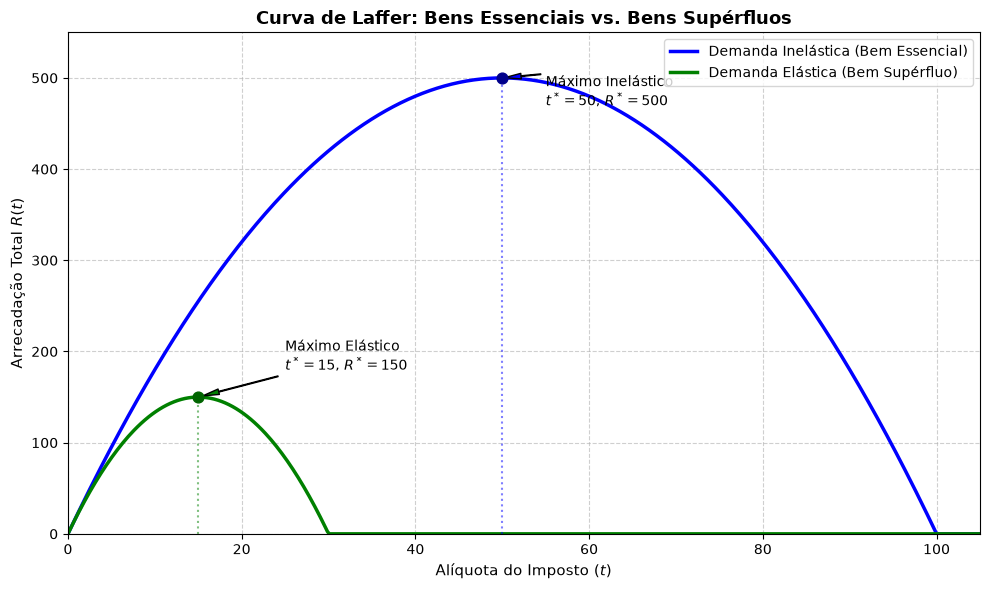

In [92]:
# Comparação por meio da curva de laffer

# Definindo o vetor de aliquotas t de 0 a 105
t = np.linspace(0, 105, 500)

# 1. Mercado Inelastico (Bem Essencial)
# Quantidade transacionada: Q = 20 - 0.2t (limitada a zero para nao haver Q negativo)
Q_in = np.maximum(0, 20 - 0.2 * t)
R_in = t * Q_in

# Ponto otimo do mercado inelastico: t = 50
t_max_in = 50
R_max_in = 20 * t_max_in - 0.2 * t_max_in**2

# 2. Mercado Elastico (Bem Superfluo)
# Quantidade transacionada: Q = 20 - (2/3)t (limitada a zero)
Q_el = np.maximum(0, 20 - (2/3) * t)
R_el = t * Q_el

# Ponto otimo do mercado elastico: t = 15
t_max_el = 15
R_max_el = 20 * t_max_el - (2/3) * t_max_el**2

# 3. Construcao do Grafico Comparativo da Curva de Laffer
plt.figure(figsize=(10, 6))

# Plotando as curvas
plt.plot(t, R_in, color='blue', linewidth=2.5, label='Demanda Inelástica (Bem Essencial)')
plt.plot(t, R_el, color='green', linewidth=2.5, label='Demanda Elástica (Bem Supérfluo)')

# Destacando os pontos de maximo (t*)
plt.scatter([t_max_in], [R_max_in], color='darkblue', zorder=5, s=60)
plt.scatter([t_max_el], [R_max_el], color='darkgreen', zorder=5, s=60)

# Linhas de referencia e anotacoes para o Bem Essencial
plt.axvline(x=t_max_in, ymax=R_max_in/550, color='blue', linestyle=':', alpha=0.5)
plt.annotate(f'Máximo Inelástico\n$t^* = {t_max_in}$, $R^* = {R_max_in:.0f}$', 
             xy=(t_max_in, R_max_in), 
             xytext=(t_max_in + 5, R_max_in - 30),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=0.5, headwidth=4))

# Linhas de referencia e anotacoes para o Bem Elastico
plt.axvline(x=t_max_el, ymax=R_max_el/550, color='green', linestyle=':', alpha=0.5)
plt.annotate(f'Máximo Elástico\n$t^* = {t_max_el}$, $R^* = {R_max_el:.0f}$', 
             xy=(t_max_el, R_max_el), 
             xytext=(t_max_el + 10, R_max_el + 30),
             arrowprops=dict(facecolor='green', shrink=0.05, width=0.5, headwidth=4))

# Formatacao do layout
plt.title('Curva de Laffer: Bens Essenciais vs. Bens Supérfluos', fontsize=13, fontweight='bold')
plt.xlabel('Alíquota do Imposto ($t$)', fontsize=11)
plt.ylabel('Arrecadação Total $R(t)$', fontsize=11)
plt.xlim(0, 105)
plt.ylim(0, 550)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

A resolução por meio do Python tem como objetivo apresentar o uso da economia computacional aplicado aos problemas de economia matemática. Essa prática não substitui o conhecimento das regras e rotinas analíticas necessárias para a álgebra linear, embora constitua um instrumento útil para identificar os efeitos de mudanças de parâmetros e suas respectivas implicações.